In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms

from src.dataset import *
from src.encoder import *
from src.decoder import *
from src.masterSemantic import *
from src.utilities import *

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
DATA_PATH = 'data/data_encdec/images/'
ANN_PATH = 'data/data_encdec/annotations/instances_default.json'
SPLIT_FILEPATH = 'data/data_encdec/train_test_split.json'
EPOCHS = 15
LEARNING_RATE = 1e-4

In [5]:
transform = transforms.Compose([
        transforms.Resize((256, 256)), 
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [6]:
train_dataset = FootballPlayerDataset(DATA_PATH, ANN_PATH, SPLIT_FILEPATH, split='train', transform=transform)
test_dataset = FootballPlayerDataset(DATA_PATH, ANN_PATH, SPLIT_FILEPATH, split='test', transform=transform)

In [7]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

### Single Stage Decoder

In [ ]:
model_single = SemanticSegmentationModel(decoder_type='single').to(device)
Loss = nn.CrossEntropyLoss()
optimizer_single = optim.Adam(model_single.parameters(), lr=LEARNING_RATE)

In [9]:
model_single = train_model(model_single, train_loader, Loss, optimizer_single, device, EPOCHS)

100%|██████████| 52/52 [00:17<00:00,  3.01it/s]


Epoch: 1/15 | Loss: 0.138


100%|██████████| 52/52 [00:18<00:00,  2.88it/s]


Epoch: 2/15 | Loss: 0.073


100%|██████████| 52/52 [00:19<00:00,  2.73it/s]


...

Epoch: 13/15 | Loss: 0.027


100%|██████████| 52/52 [00:16<00:00,  3.10it/s]


Epoch: 14/15 | Loss: 0.026


100%|██████████| 52/52 [00:16<00:00,  3.10it/s]

Epoch: 15/15 | Loss: 0.025


In [10]:
acc_single, miou_single = evaluation(model_single, test_loader, device)
print(f"Single Stage | Test Pixel Accuracy: {acc_single * 100:.2f}%")
print(f"Single Stage | Test mIoU: {miou_single:.4f}")

Single Stage | Test Pixel Accuracy: 98.70%
Single Stage | Test mIoU: 0.7063


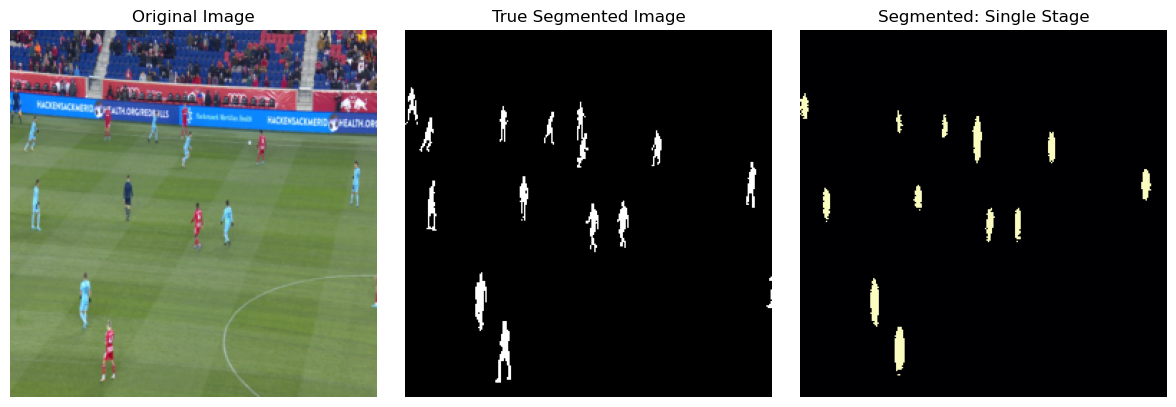

In [11]:
visualize({'Single Stage': model_single}, test_loader, device, num_images=1)

### Progressive Decoder

In [ ]:
model_prog = SemanticSegmentationModel(decoder_type='progressive').to(device)
Loss = nn.CrossEntropyLoss()
optimizer_prog = optim.Adam(model_prog.parameters(), lr=LEARNING_RATE)

In [13]:
model_prog = train_model(model_prog, train_loader, Loss, optimizer_prog, device, EPOCHS)

100%|██████████| 52/52 [00:16<00:00,  3.11it/s]


Epoch: 1/15 | Loss: 0.347


100%|██████████| 52/52 [00:16<00:00,  3.18it/s]


Epoch: 2/15 | Loss: 0.104


100%|██████████| 52/52 [00:16<00:00,  3.23it/s]


...

Epoch: 13/15 | Loss: 0.023


100%|██████████| 52/52 [00:17<00:00,  3.05it/s]


Epoch: 14/15 | Loss: 0.022


100%|██████████| 52/52 [00:16<00:00,  3.09it/s]

Epoch: 15/15 | Loss: 0.021


In [14]:
acc_prog, miou_prog = evaluation(model_prog, test_loader, device)
print(f"Progressive | Test Pixel Accuracy: {acc_prog * 100:.2f}%")
print(f"Progressive | Test mIoU: {miou_prog:.4f}")

Progressive | Test Pixel Accuracy: 99.15%
Progressive | Test mIoU: 0.7992


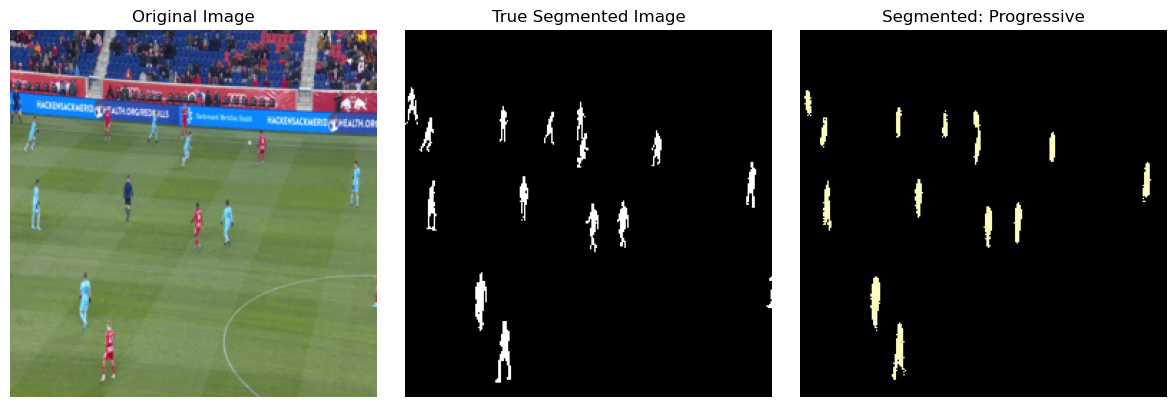

In [15]:
visualize({'Progressive': model_prog}, test_loader, device, num_images=1)

### Compare Both Visually

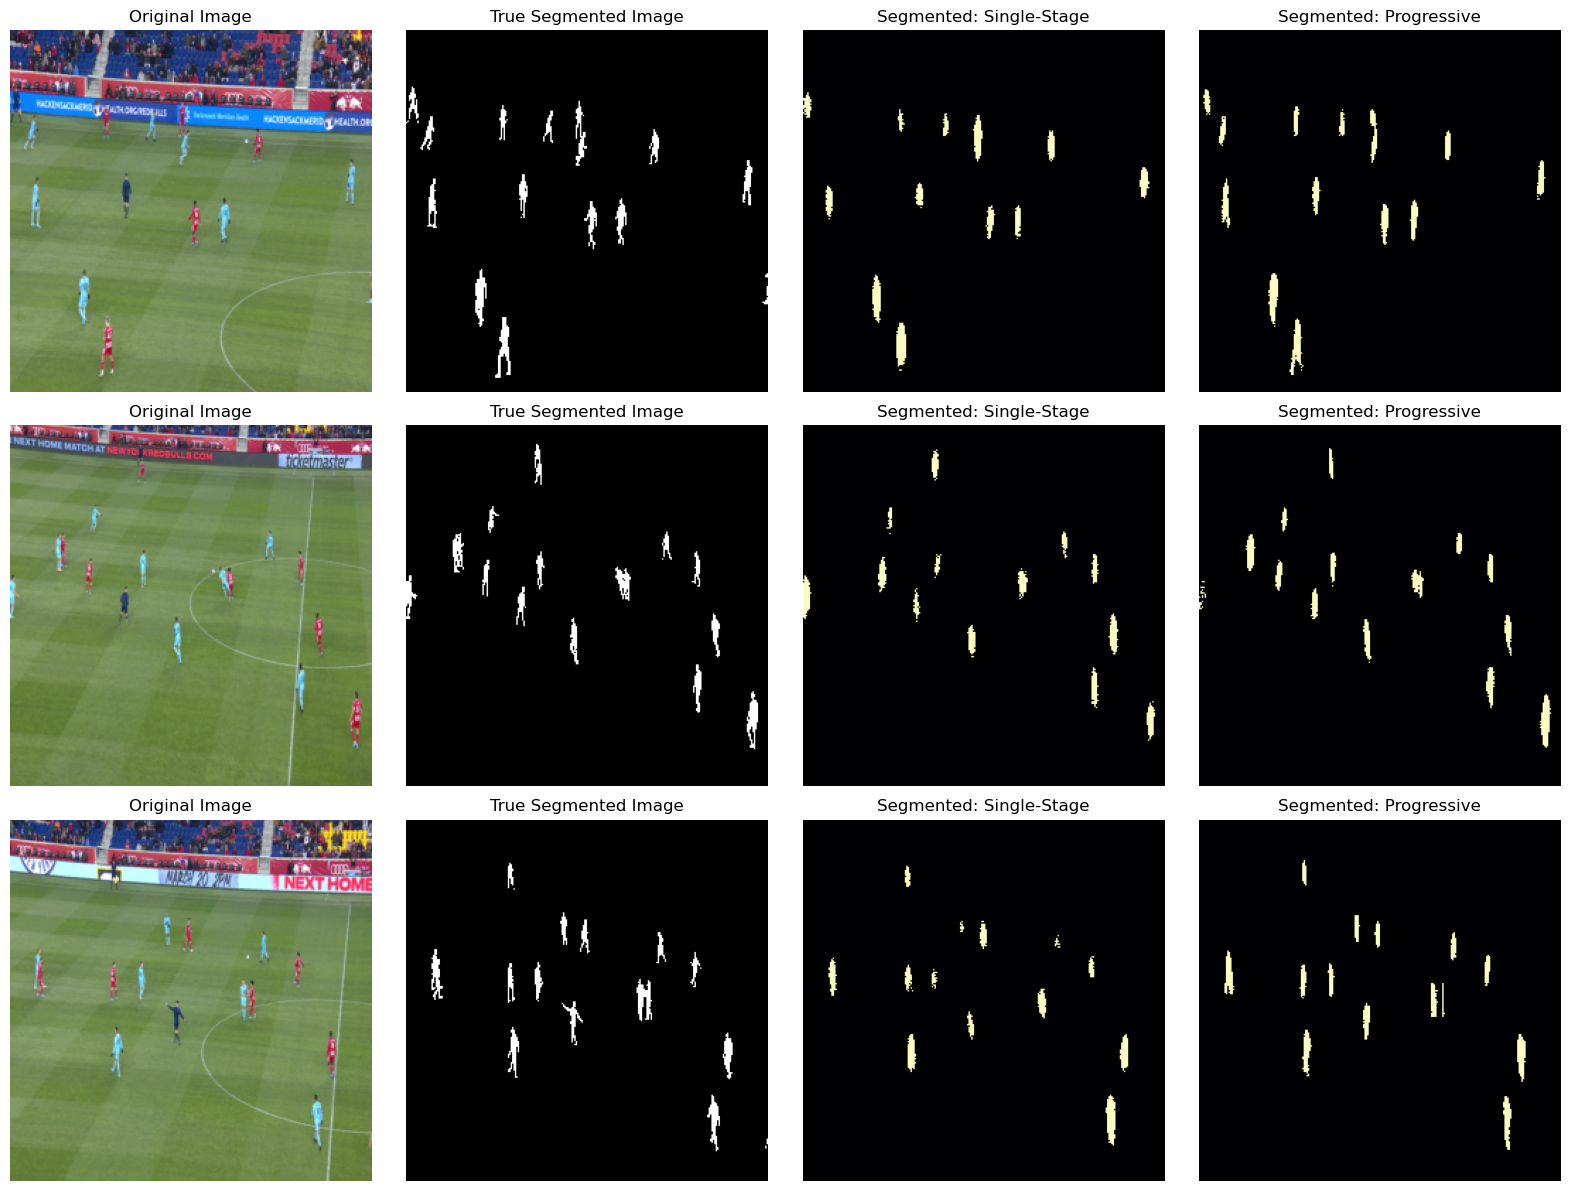

In [16]:
visualize(
    {'Single-Stage': model_single, 'Progressive': model_prog}, 
    test_loader, 
    device, 
    num_images=3
)